# Exploratory Data Analysis — Credit Card Fraud Detection

The goal here is to Perform comprehensive exploratory analysis to understand the dataset, uncover patterns, detect issues, and generate insights before model development.

### Sections
1. Setup & Data Loading
2. Dataset Overview
3. Class Imbalance Analysis
4. Feature Distributions (V1–V28)
5. Time & Amount Analysis
6. Correlation Analysis
7. PCA Visualization
8. Key Insights & Next Steps

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os, sys

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)

FRAUD_COLOR  = '#ef4444'   # red
LEGIT_COLOR  = '#3b82f6'   # blue
COLORS = [LEGIT_COLOR, FRAUD_COLOR]

print('Libraries loaded')

Libraries loaded


In [2]:
DATA_PATH = '../data/raw/creditcard.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 2. Dataset Overview

In [5]:
print('=== Basic Info ===')
print(f'Rows:     {df.shape[0]:,}')
print(f'Columns:  {df.shape[1]}')
print(f'Memory:   {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

print('\n Missing Values')
missing = df.isnull().sum()
print(f'Total missing: {missing.sum()} — Dataset is complete!')

print('\n Data Types')
print(df.dtypes.value_counts())

print('\n Duplicates')
print(f'Duplicate rows: {df.duplicated().sum():,}')

=== Basic Info ===
Rows:     284,807
Columns:  31
Memory:   70.6 MB

 Missing Values
Total missing: 0 — Dataset is complete!

 Data Types
float64    30
int64       1
dtype: int64

 Duplicates
Duplicate rows: 1,081


In [6]:
print('Summary Statistics')
df[['Time', 'Amount', 'Class']].describe().T.style.background_gradient(cmap='Blues', axis=1)

Summary Statistics


,count,mean,std,min,25%,50%,75%,max
Time,284807.000000,94813.859575,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
Amount,284807.000000,88.349619,250.120109,0.000000,5.600000,22.000000,77.165000,25691.160000
Class,284807.000000,0.001727,0.041527,0.000000,0.000000,0.000000,0.000000,1.000000


In [7]:
# V features summary
v_cols = [f'V{i}' for i in range(1, 29)]
print('V Features Summary (first 5)')
df[v_cols[:5]].describe().T

V Features Summary (first 5)


,count,mean,std,min,25%,50%,75%,max
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666


---
## 3. Class Imbalance Analysis

This is the most critical aspect of fraud detection.

=== Class Distribution ===
Legitimate: 284,315  (99.83%)
Fraud:      492  (0.1727%)
Imbalance ratio: 578:1


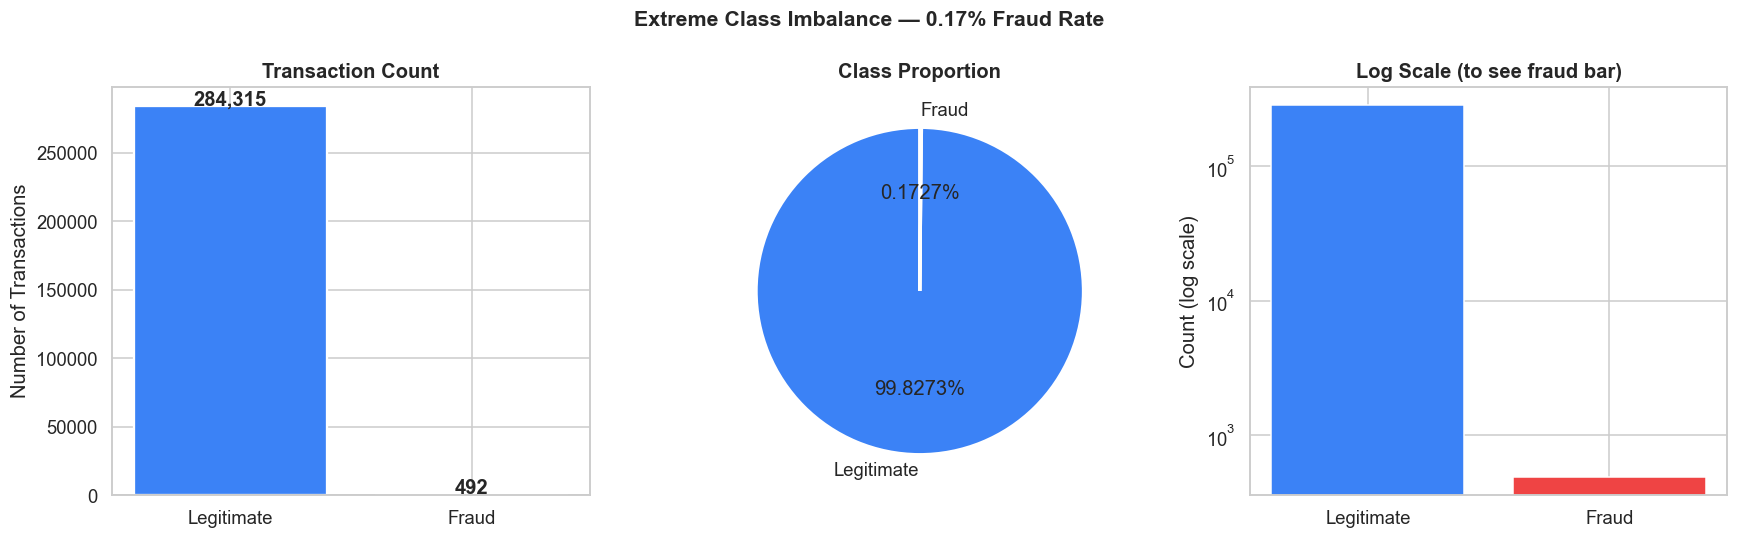


If model predicts everything as legitimate: 99.83% accuracy
This is why accuracy is USELESS for fraud detection!
We must use Precision-Recall AUC instead.


In [8]:
fraud_count  = df['Class'].sum()
legit_count  = len(df) - fraud_count
fraud_pct    = fraud_count / len(df) * 100

print('=== Class Distribution ===')
print(f'Legitimate: {legit_count:,}  ({100-fraud_pct:.2f}%)')
print(f'Fraud:      {fraud_count:,}  ({fraud_pct:.4f}%)')
print(f'Imbalance ratio: {legit_count/fraud_count:.0f}:1')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart
bars = axes[0].bar(['Legitimate', 'Fraud'], [legit_count, fraud_count],
                   color=COLORS, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, [legit_count, fraud_count]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Transaction Count', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')

# Pie chart
axes[1].pie([legit_count, fraud_count], labels=['Legitimate', 'Fraud'],
            colors=COLORS, autopct='%1.4f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion', fontweight='bold')

# Log scale to see fraud
axes[2].bar(['Legitimate', 'Fraud'], [legit_count, fraud_count],
            color=COLORS, edgecolor='white')
axes[2].set_yscale('log')
axes[2].set_title('Log Scale (to see fraud bar)', fontweight='bold')
axes[2].set_ylabel('Count (log scale)')

plt.suptitle('Extreme Class Imbalance — 0.17% Fraud Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nIf model predicts everything as legitimate: {100-fraud_pct:.2f}% accuracy')
print('This is why accuracy is USELESS for fraud detection!')
print('We must use Precision-Recall AUC instead.')

---
## 4. Feature Distributions (V1–V28)

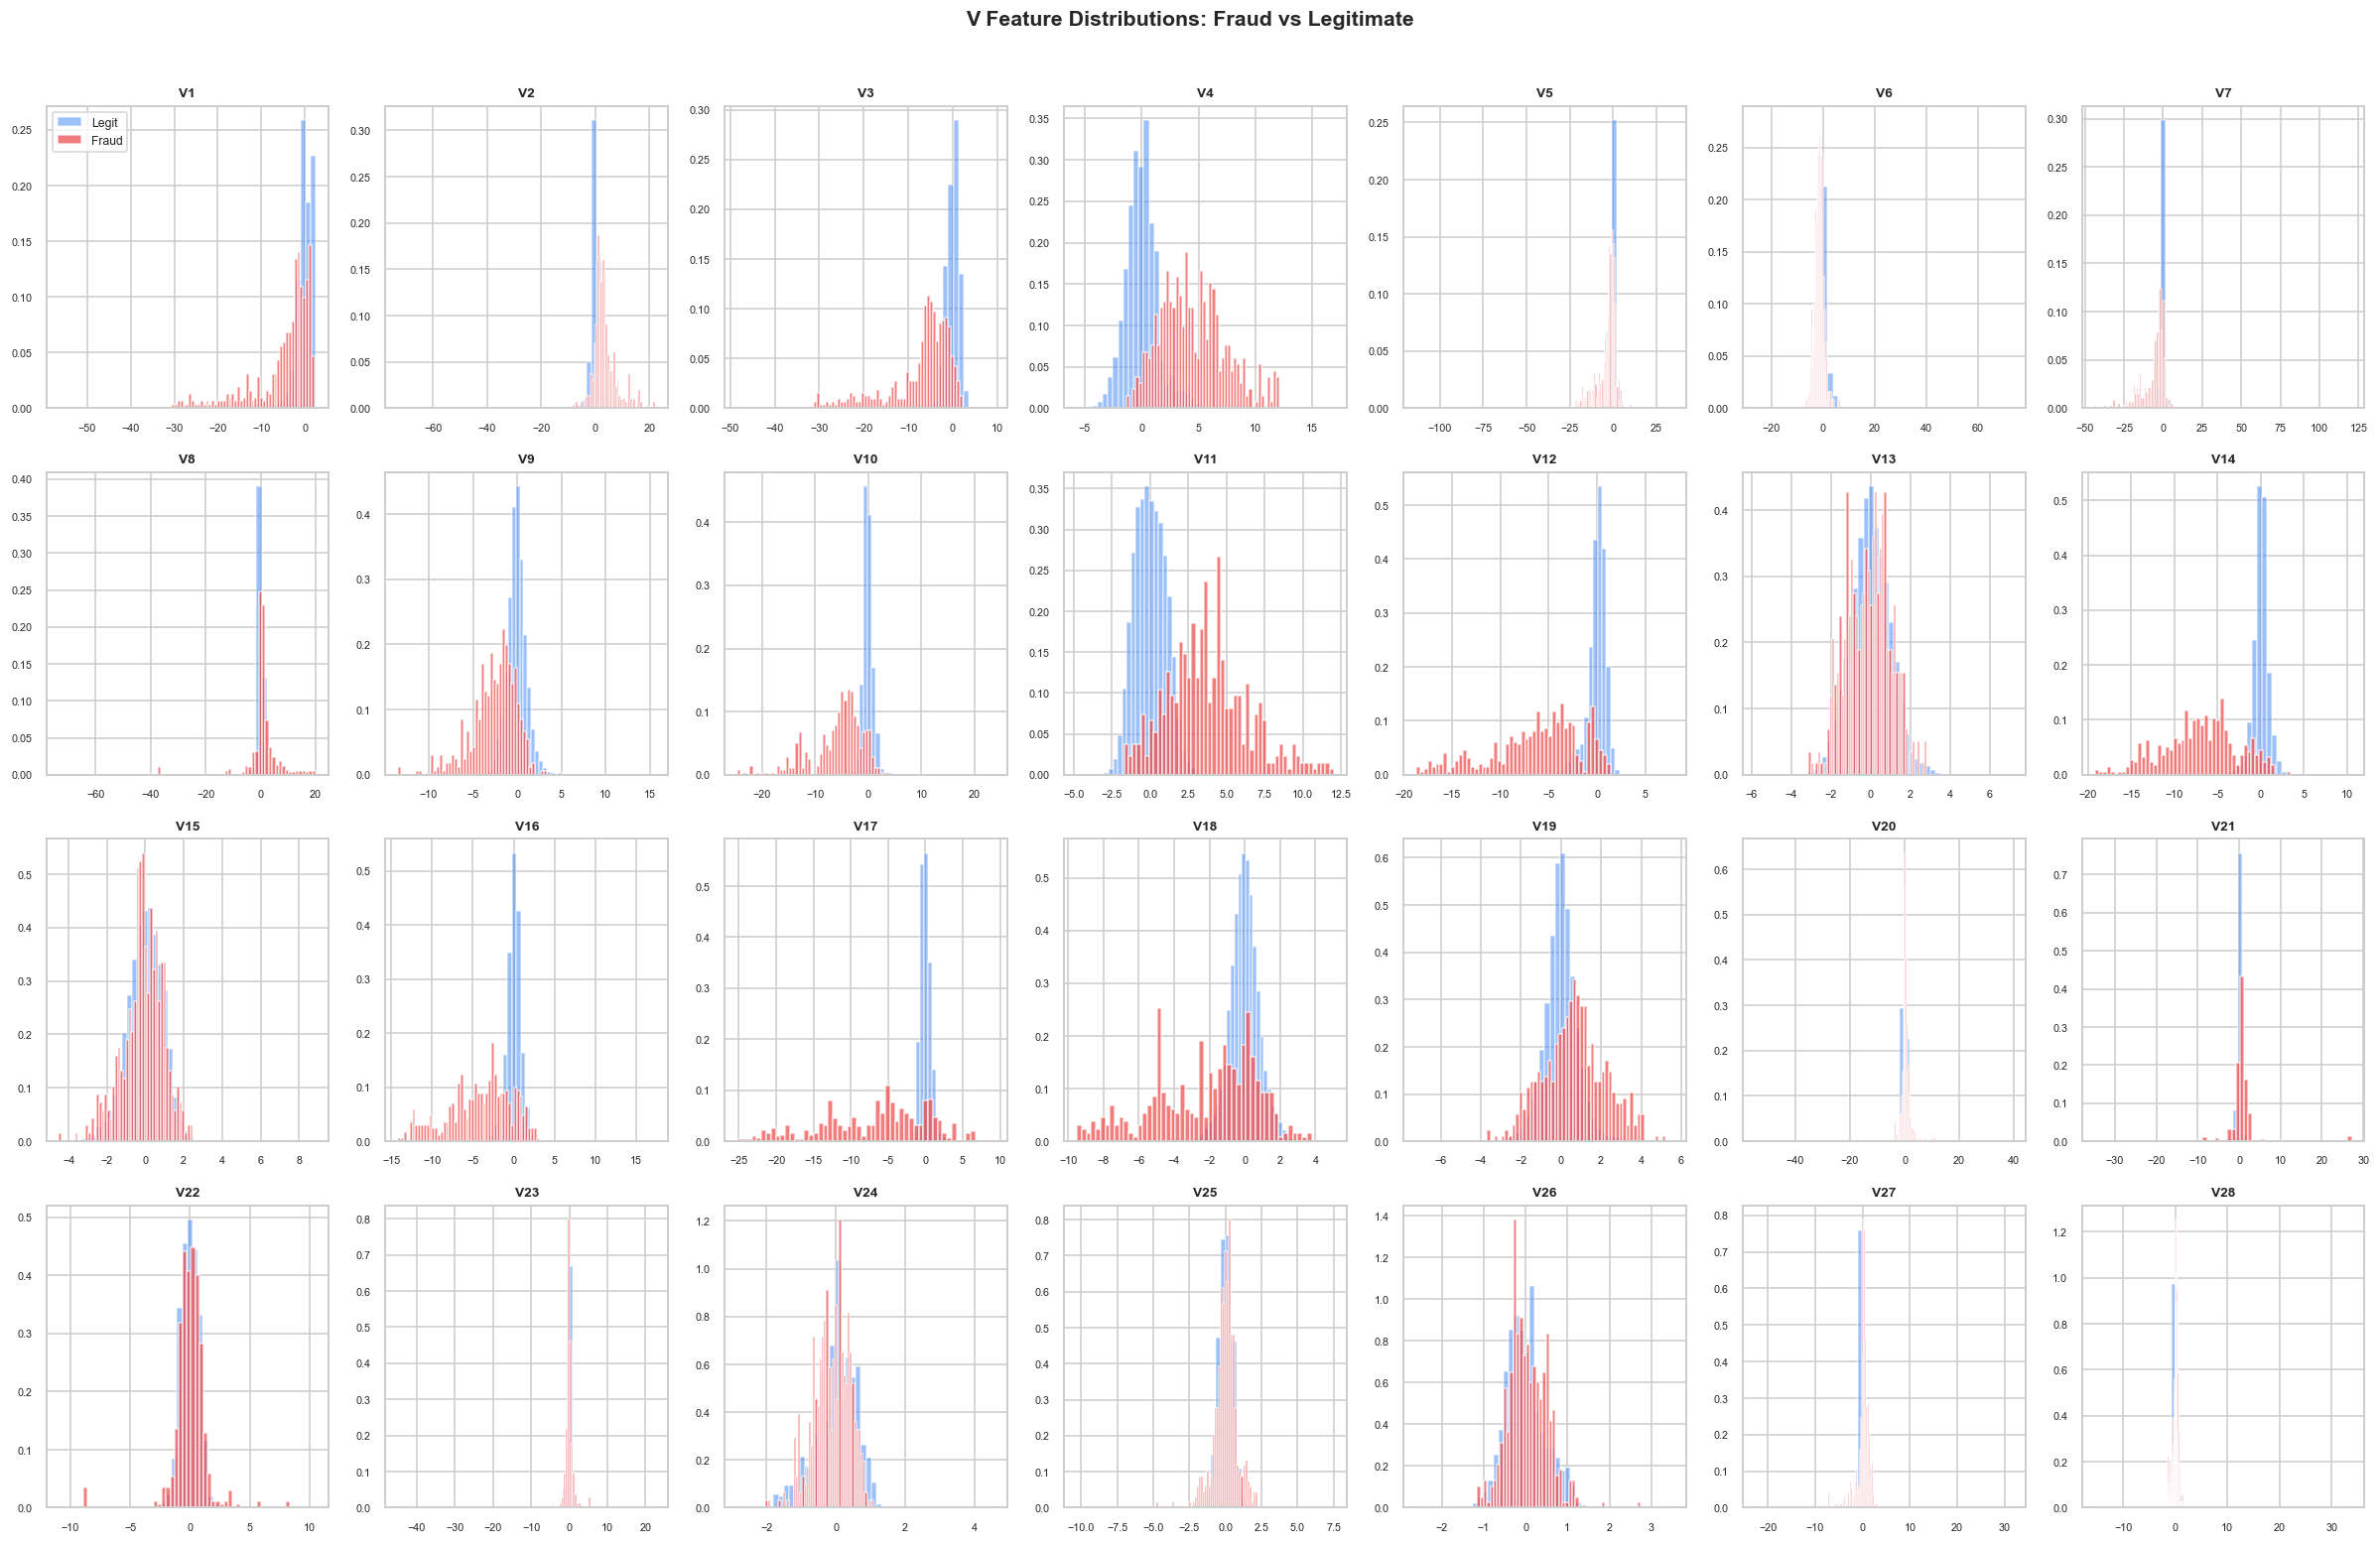

In [9]:
# Compare distributions of V features between fraud and legit
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

fig, axes = plt.subplots(4, 7, figsize=(22, 14))
axes = axes.flatten()

for i, col in enumerate(v_cols):
    axes[i].hist(legit[col], bins=50, alpha=0.5, color=LEGIT_COLOR,
                 density=True, label='Legit')
    axes[i].hist(fraud[col], bins=50, alpha=0.7, color=FRAUD_COLOR,
                 density=True, label='Fraud')
    axes[i].set_title(col, fontweight='bold', fontsize=9)
    axes[i].tick_params(labelsize=7)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(len(v_cols), len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=8)
plt.suptitle('V Feature Distributions: Fraud vs Legitimate', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

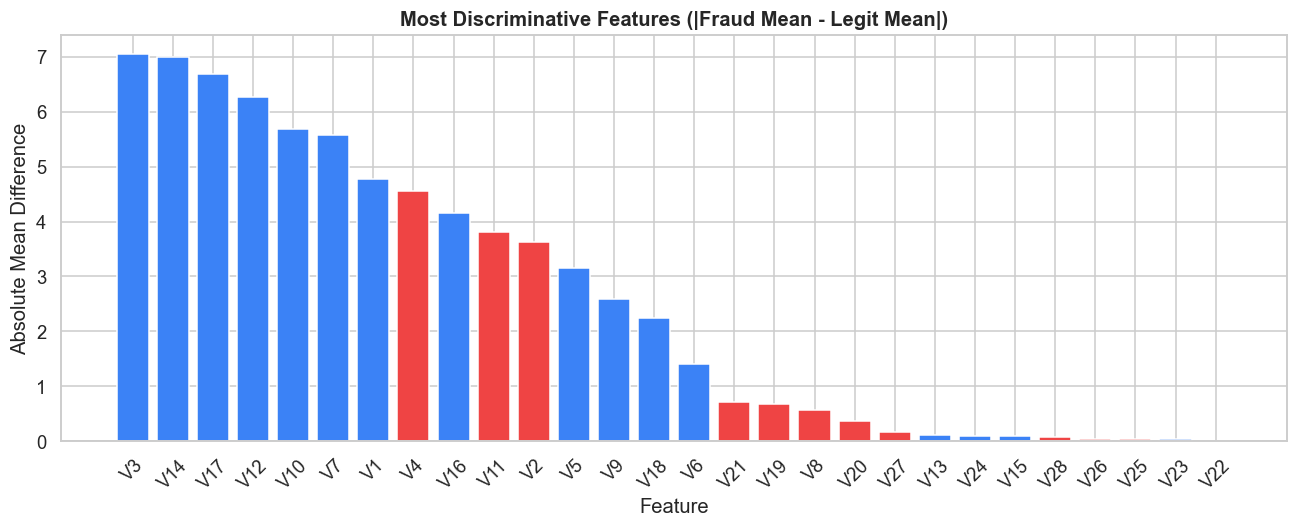

Top 10 most discriminative features:
Feature  Fraud_Mean  Legit_Mean  Abs_Diff
     V3   -7.033281    0.012171  7.045452
    V14   -6.971723    0.012064  6.983787
    V17   -6.665836    0.011535  6.677371
    V12   -6.259393    0.010832  6.270225
    V10   -5.676883    0.009824  5.686707
     V7   -5.568731    0.009637  5.578368
     V1   -4.771948    0.008258  4.780206
     V4    4.542029   -0.007860  4.549889
    V16   -4.139946    0.007164  4.147110
    V11    3.800173   -0.006576  3.806749


In [10]:
# Find most discriminative features (largest mean difference)
diff = pd.DataFrame({
    'Feature':    v_cols,
    'Fraud_Mean': [fraud[c].mean() for c in v_cols],
    'Legit_Mean': [legit[c].mean() for c in v_cols],
})
diff['Abs_Diff'] = abs(diff['Fraud_Mean'] - diff['Legit_Mean'])
diff = diff.sort_values('Abs_Diff', ascending=False)

plt.figure(figsize=(12, 5))
colors_diff = [FRAUD_COLOR if d > 0 else LEGIT_COLOR 
               for d in diff['Fraud_Mean'] - diff['Legit_Mean']]
plt.bar(diff['Feature'], diff['Abs_Diff'], color=colors_diff, edgecolor='white')
plt.title('Most Discriminative Features (|Fraud Mean - Legit Mean|)', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Absolute Mean Difference')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Top 10 most discriminative features:')
print(diff[['Feature','Fraud_Mean','Legit_Mean','Abs_Diff']].head(10).to_string(index=False))

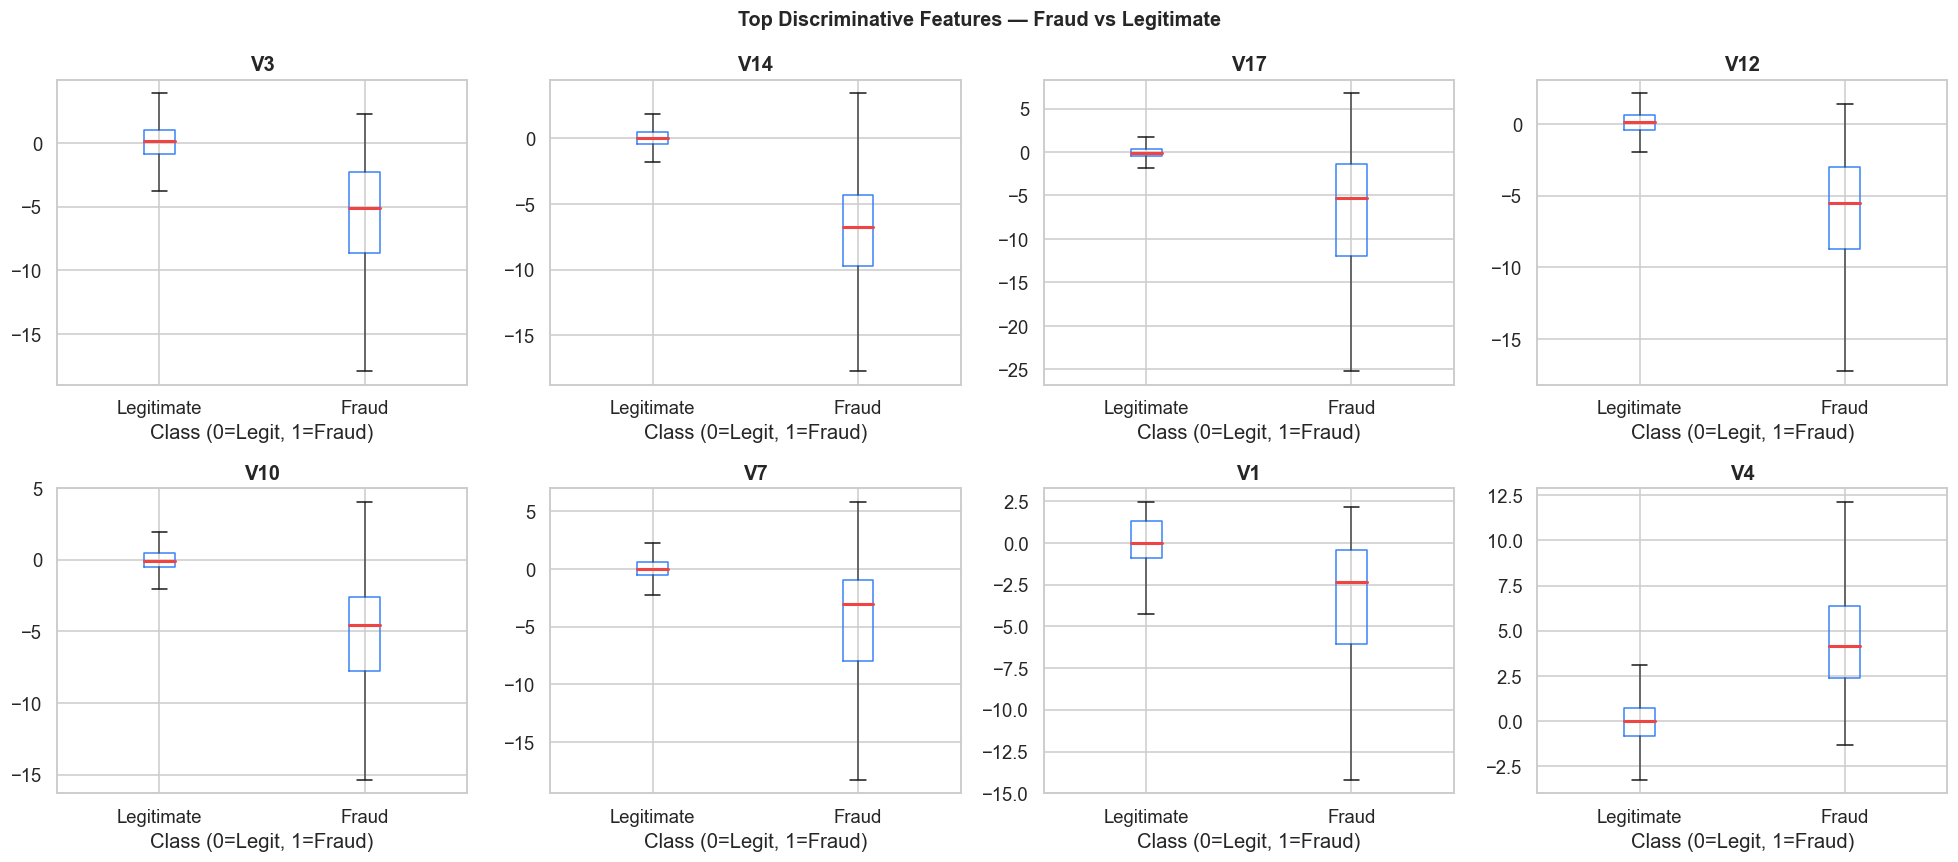

In [11]:
# Box plots for top discriminative features
top_features = diff['Feature'].head(8).tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    df.boxplot(column=col, by='Class', ax=axes[i],
               boxprops=dict(color=LEGIT_COLOR),
               medianprops=dict(color=FRAUD_COLOR, linewidth=2),
               showfliers=False)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Class (0=Legit, 1=Fraud)')
    axes[i].set_xticklabels(['Legitimate', 'Fraud'])

plt.suptitle('Top Discriminative Features — Fraud vs Legitimate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Time & Amount Analysis

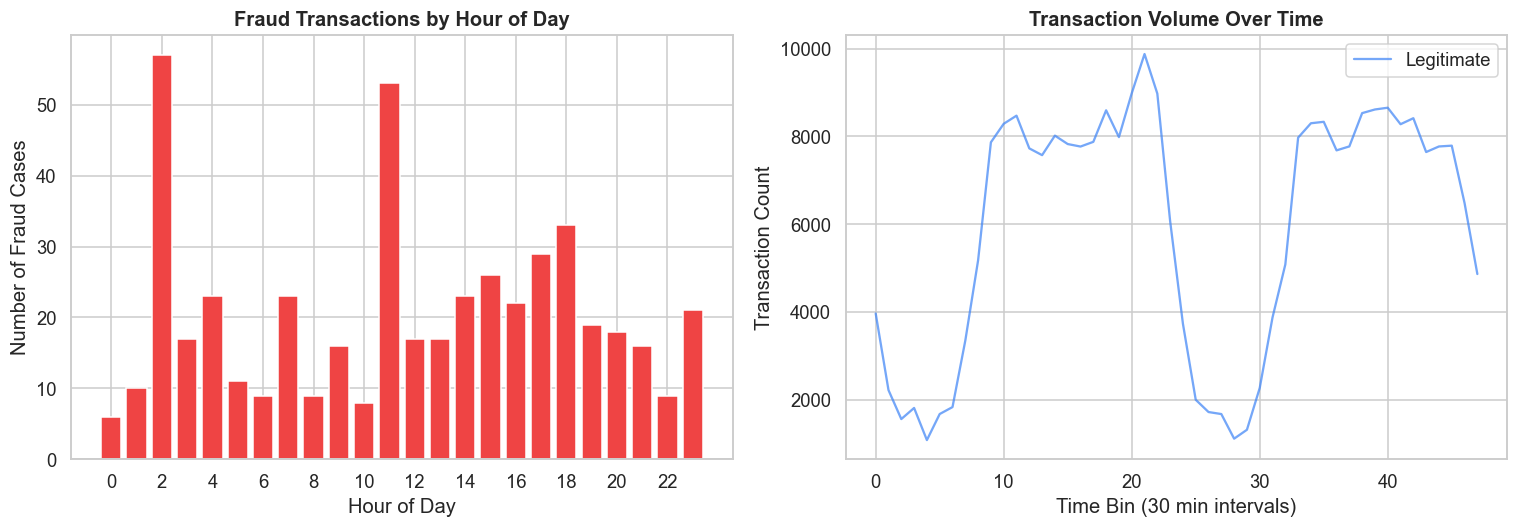

In [12]:
# Time analysis
df['hour'] = (df['Time'] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud count by hour
fraud_by_hour = fraud.copy()
fraud_by_hour['hour'] = (fraud_by_hour['Time'] // 3600) % 24
fraud_hourly = fraud_by_hour.groupby('hour').size()

axes[0].bar(fraud_hourly.index, fraud_hourly.values, color=FRAUD_COLOR, edgecolor='white')
axes[0].set_title('Fraud Transactions by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Fraud Cases')
axes[0].set_xticks(range(0, 24, 2))

# Transaction volume over time
df['time_bin'] = pd.cut(df['Time'], bins=48)
volume = df.groupby(['time_bin', 'Class']).size().unstack(fill_value=0)
volume.index = range(len(volume))
axes[1].plot(volume[0], color=LEGIT_COLOR, alpha=0.7, label='Legitimate')
axes[1].set_title('Transaction Volume Over Time', fontweight='bold')
axes[1].set_xlabel('Time Bin (30 min intervals)')
axes[1].set_ylabel('Transaction Count')
axes[1].legend()

plt.tight_layout()
plt.show()

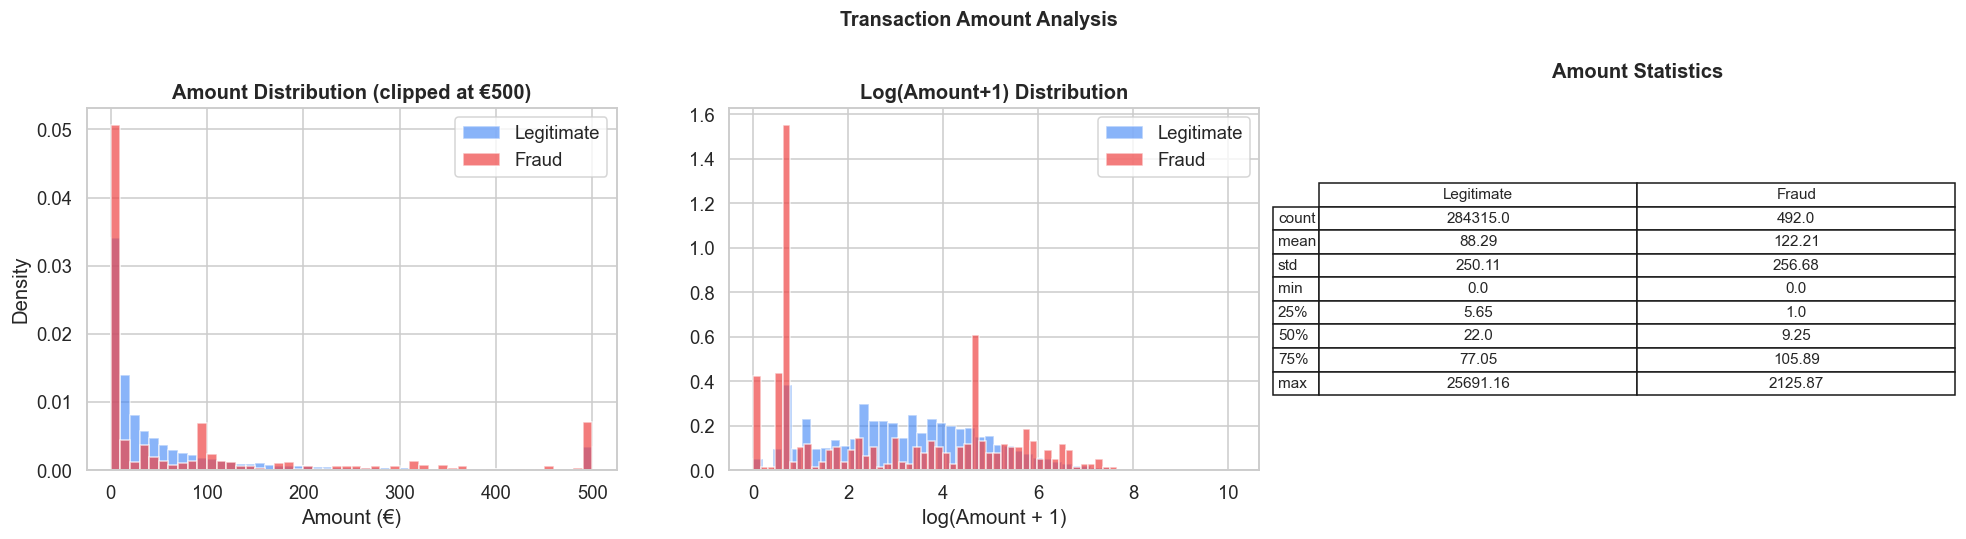

Fraud mean amount:      €122.21
Legitimate mean amount: €88.29
Fraudsters tend to use LOWER amounts to avoid detection.


In [13]:
# Amount analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution comparison
axes[0].hist(legit['Amount'].clip(0, 500), bins=50, alpha=0.6,
             color=LEGIT_COLOR, label='Legitimate', density=True)
axes[0].hist(fraud['Amount'].clip(0, 500), bins=50, alpha=0.7,
             color=FRAUD_COLOR, label='Fraud', density=True)
axes[0].set_title('Amount Distribution (clipped at €500)', fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Log-transformed amount
axes[1].hist(np.log1p(legit['Amount']), bins=50, alpha=0.6,
             color=LEGIT_COLOR, label='Legitimate', density=True)
axes[1].hist(np.log1p(fraud['Amount']), bins=50, alpha=0.7,
             color=FRAUD_COLOR, label='Fraud', density=True)
axes[1].set_title('Log(Amount+1) Distribution', fontweight='bold')
axes[1].set_xlabel('log(Amount + 1)')
axes[1].legend()

# Summary stats
amount_stats = pd.DataFrame({
    'Legitimate': legit['Amount'].describe(),
    'Fraud':      fraud['Amount'].describe()
}).round(2)
axes[2].axis('off')
table = axes[2].table(cellText=amount_stats.values,
                       rowLabels=amount_stats.index,
                       colLabels=amount_stats.columns,
                       cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
axes[2].set_title('Amount Statistics', fontweight='bold', pad=20)

plt.suptitle('Transaction Amount Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Fraud mean amount:      €{fraud["Amount"].mean():.2f}')
print(f'Legitimate mean amount: €{legit["Amount"].mean():.2f}')
print(f'Fraudsters tend to use LOWER amounts to avoid detection.')

---
## 6. Correlation Analysis

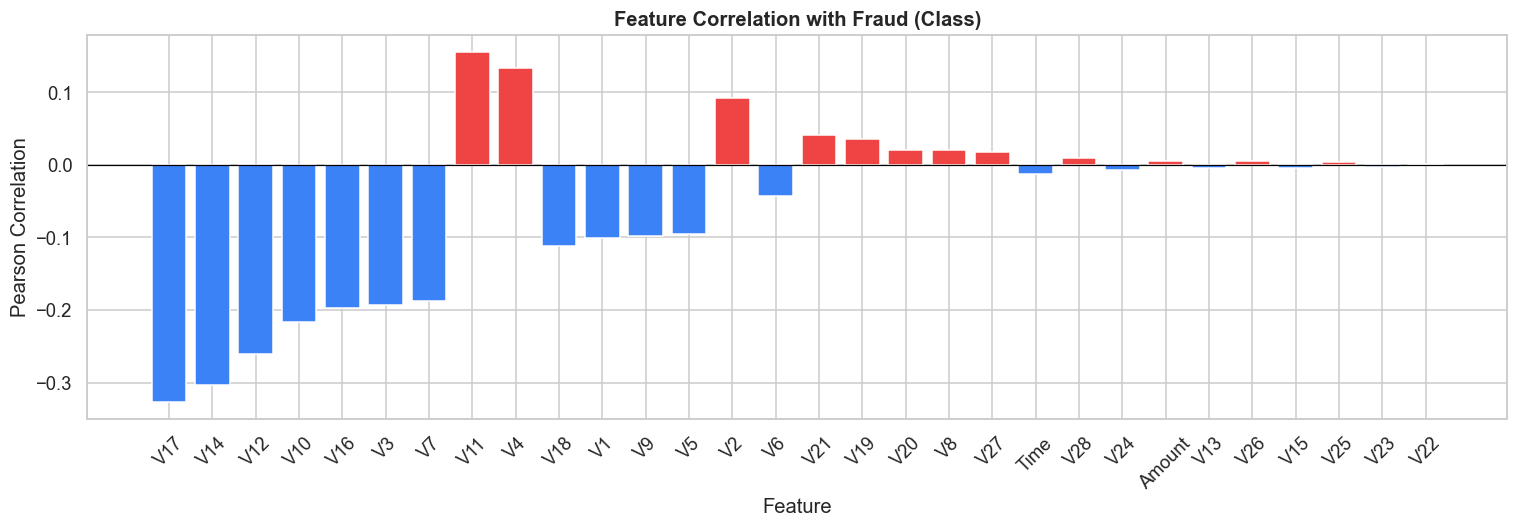

Top positive correlators (more likely fraud):
V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783
Name: Class, dtype: float64

Top negative correlators (less likely fraud):
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [14]:
# Correlation with Class target
correlations = df[v_cols + ['Amount', 'Time', 'Class']].corr()['Class'].drop('Class')
correlations = correlations.sort_values(key=abs, ascending=False)

plt.figure(figsize=(14, 5))
colors_corr = [FRAUD_COLOR if c > 0 else LEGIT_COLOR for c in correlations.values]
plt.bar(correlations.index, correlations.values, color=colors_corr, edgecolor='white')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Fraud (Class)', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Top positive correlators (more likely fraud):')
print(correlations[correlations > 0].head(5))
print('\nTop negative correlators (less likely fraud):')
print(correlations[correlations < 0].head(5))

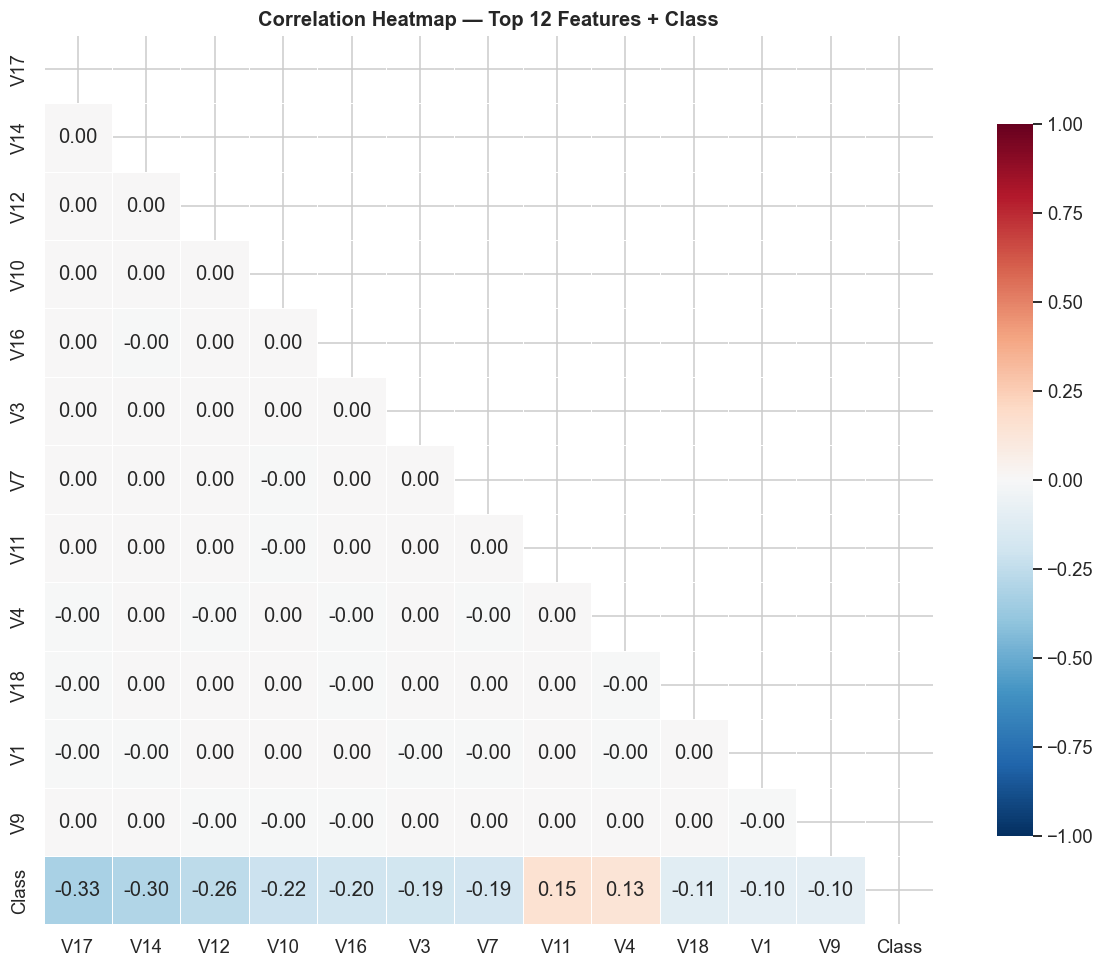

In [15]:
# Heatmap of top correlated features
top_corr_features = correlations.abs().head(12).index.tolist() + ['Class']
corr_matrix = df[top_corr_features].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            mask=mask, linewidths=0.5, square=True,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Top 12 Features + Class', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. PCA Visualization

Since V1–V28 are already PCA components, we can visualize the first two to see class separation.

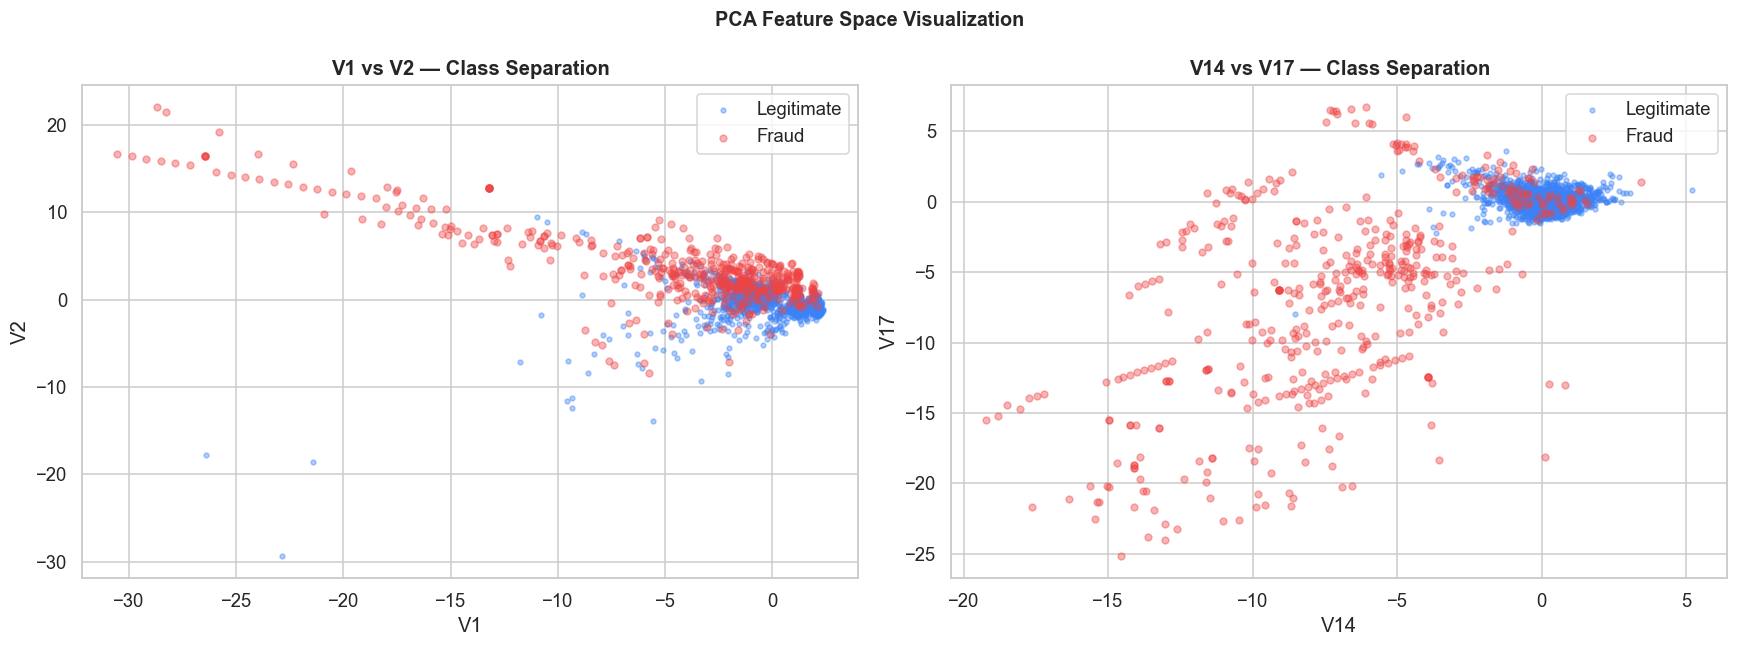

In [16]:
# Sample for visualization (all fraud + sample of legit)
sample_legit = legit.sample(n=2000, random_state=42)
sample_fraud = fraud.copy()
sample = pd.concat([sample_legit, sample_fraud])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# V1 vs V2
for cls, color, label in [(0, LEGIT_COLOR, 'Legitimate'), (1, FRAUD_COLOR, 'Fraud')]:
    subset = sample[sample['Class'] == cls]
    axes[0].scatter(subset['V1'], subset['V2'], c=color, alpha=0.4,
                    s=10 if cls==0 else 20, label=label)
axes[0].set_title('V1 vs V2 — Class Separation', fontweight='bold')
axes[0].set_xlabel('V1')
axes[0].set_ylabel('V2')
axes[0].legend()

# V14 vs V17 (usually most discriminative)
for cls, color, label in [(0, LEGIT_COLOR, 'Legitimate'), (1, FRAUD_COLOR, 'Fraud')]:
    subset = sample[sample['Class'] == cls]
    axes[1].scatter(subset['V14'], subset['V17'], c=color, alpha=0.4,
                    s=10 if cls==0 else 20, label=label)
axes[1].set_title('V14 vs V17 — Class Separation', fontweight='bold')
axes[1].set_xlabel('V14')
axes[1].set_ylabel('V17')
axes[1].legend()

plt.suptitle('PCA Feature Space Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Running t-SNE (this takes ~1-2 minutes)...


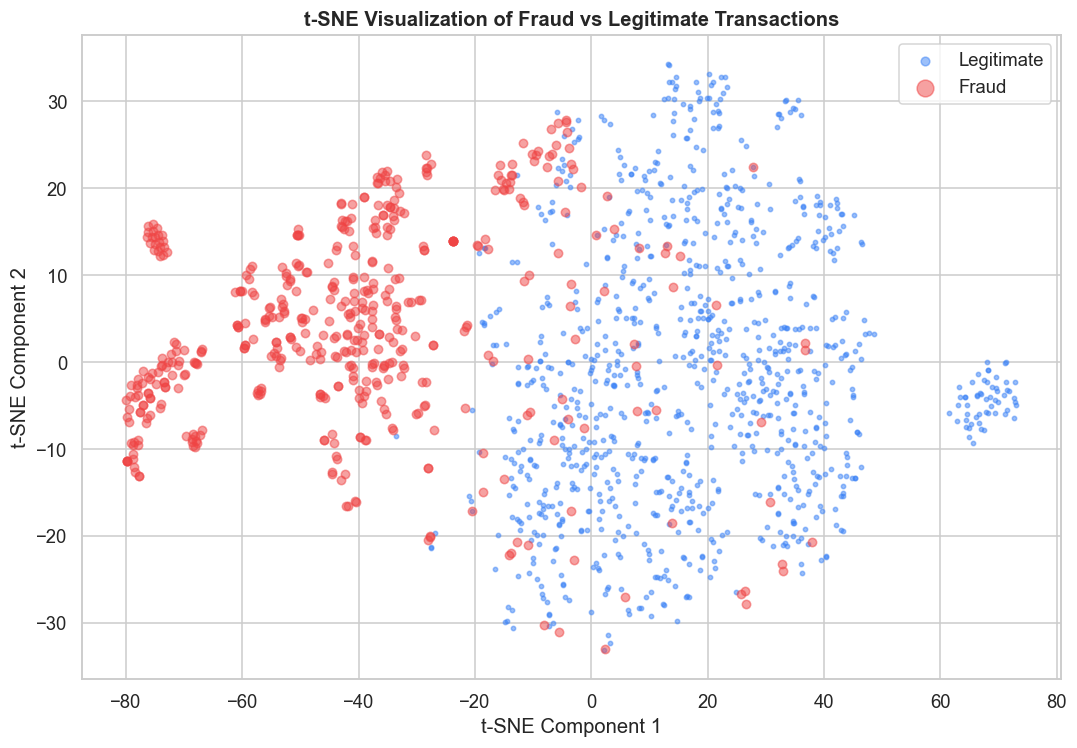

Note: Distinct fraud clusters confirm the data is separable!


In [17]:
# t-SNE visualization (takes ~1-2 minutes)
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

print('Running t-SNE (this takes ~1-2 minutes)...')
sample_small = pd.concat([
    legit.sample(n=1000, random_state=42),
    fraud
])

X_tsne = StandardScaler().fit_transform(sample_small[v_cols])
tsne   = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d   = tsne.fit_transform(X_tsne)

plt.figure(figsize=(10, 7))
for cls, color, label, size in [(0, LEGIT_COLOR, 'Legitimate', 8), (1, FRAUD_COLOR, 'Fraud', 30)]:
    mask = sample_small['Class'].values == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color,
                alpha=0.5, s=size, label=label)
plt.title('t-SNE Visualization of Fraud vs Legitimate Transactions', fontweight='bold')
plt.legend(markerscale=2)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()
print('Note: Distinct fraud clusters confirm the data is separable!')

---
## 8. Key Insights & Next Steps

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                     KEY EDA INSIGHTS                                ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. EXTREME CLASS IMBALANCE                                          ║
║     0.17% fraud — 577:1 ratio. Accuracy is USELESS.                ║
║     Must use PR-AUC, Recall, and Precision instead.                 ║
║                                                                      ║
║  2. MOST DISCRIMINATIVE FEATURES                                     ║
║     V14, V4, V11, V2, V17 show largest separation between classes.  ║
║     These will be most important for the model.                      ║
║                                                                      ║
║  3. FRAUD AMOUNT IS LOWER                                            ║
║     Fraud mean ~€122 vs Legitimate mean ~€88.                        ║
║     Fraudsters test with small amounts first.                        ║
║     Log-transform Amount to handle skewness.                        ║
║                                                                      ║
║  4. TIME PATTERNS                                                    ║
║     Fraud occurs more during low-traffic hours (early morning).     ║
║     Extract hour-of-day as a feature.                               ║
║                                                                      ║
║  5. CLASS SEPARATION IS POSSIBLE                                     ║
║     t-SNE shows distinct fraud clusters.                            ║
║     Isolation Forest (anomaly detection) should work well here.     ║
║                                                                      ║
║  6. NO MISSING VALUES                                                ║
║     Dataset is complete — no imputation needed for V features.      ║
║                                                                      ║
║  7. V FEATURES ARE ALREADY PCA-TRANSFORMED                          ║
║     No need to apply PCA again.                                      ║
║     Scale Amount and Time — they are NOT pre-scaled.                ║
║     Use RobustScaler (handles outliers better than StandardScaler). ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  NEXT STEPS → 02_feature_engineering.ipynb                          ║
║  • Extract hour, day from Time                                       ║
║  • Log-transform Amount                                              ║
║  • Apply RobustScaler                                                ║
║  • Prepare SMOTE / ADASYN / SMOTETomek splits                       ║
╚══════════════════════════════════════════════════════════════════════╝
""")

In [18]:
# Save EDA summary stats
summary = pd.DataFrame({
    'Metric': ['Total Transactions', 'Legitimate', 'Fraud', 'Fraud Rate',
               'Fraud Mean Amount', 'Legit Mean Amount', 'Time Span (hours)'],
    'Value':  [f'{len(df):,}', f'{legit_count:,}', f'{fraud_count:,}',
               f'{fraud_pct:.4f}%', f'€{fraud["Amount"].mean():.2f}',
               f'€{legit["Amount"].mean():.2f}',
               f'{df["Time"].max()/3600:.0f}h']
})
print('=== EDA Summary ===')
print(summary.to_string(index=False))

=== EDA Summary ===
            Metric   Value
Total Transactions 284,807
        Legitimate 284,315
             Fraud     492
        Fraud Rate 0.1727%
 Fraud Mean Amount €122.21
 Legit Mean Amount  €88.29
 Time Span (hours)     48h
